# 🔧 Assignment: Basic Anomaly Detection for Cybersecurity Logs
## Synthetic Authentication Event Analysis
---
* **Student Name:** Tal Berkovitch
* **Topic:** Anomalous Login Detection
* **Dataset:** Synthetically generated Authentication Logs
* **MITRE ATT&CK Techniques:**
    * *T1110: Brute Force*
    * *T1078: Valid Accounts (Insider Threat/Compromised Credentials)*
---

### 1. Prepare a Cybersecurity-Related Dataset
Since network traffic (like KDD or UNSW-NB15) is very common, I decided to generate a synthetic dataset focused purely on **Authentication Logs**.

The dataset consists of 10,000 login events:
* **Normal Traffic (98%):** Users logging in during standard business hours (8 AM - 6 PM) with a standard session duration and very few failed login attempts.
* **Anomalous Traffic (2%):** Malicious behavior simulating Brute Force attacks (high failed logins) and compromised valid accounts logging in at unusual hours (e.g., 2 AM - 4 AM) with unusually short session durations (smash-and-grab data exfiltration or reconnaissance).

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

# Set plotting style
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# SYNTHETIC DATA GENERATION
# ---------------------------------------------------------
np.random.seed(42)
n_total = 10000
contamination_rate = 0.02
n_anomaly = int(n_total * contamination_rate)
n_normal = n_total - n_anomaly

# Generate Normal Data (Business hours, low failed logins, stable sessions)
normal_failed = np.random.poisson(lam=0.2, size=n_normal) # Very few failed logins
normal_hour = np.random.normal(loc=13, scale=3, size=n_normal) # Centered around 1 PM
normal_duration = np.random.normal(loc=120, scale=30, size=n_normal) # ~120 minute sessions

# Generate Anomalous Data (Brute force & weird hours)
anomaly_failed = np.random.poisson(lam=12.0, size=n_anomaly) # High failed logins (Brute Force)
anomaly_hour = np.random.normal(loc=3, scale=1.5, size=n_anomaly) # Centered around 3 AM
anomaly_duration = np.random.exponential(scale=10, size=n_anomaly) # Very short sessions

# Construct DataFrames
df_normal = pd.DataFrame({'failed_logins': normal_failed, 'hour': normal_hour, 'session_duration_mins': normal_duration, 'is_attack': 0})
df_anomaly = pd.DataFrame({'failed_logins': anomaly_failed, 'hour': anomaly_hour, 'session_duration_mins': anomaly_duration, 'is_attack': 1})

# Combine, shuffle, and clean up hours to be valid 24hr format
df = pd.concat([df_normal, df_anomaly]).sample(frac=1, random_state=42).reset_index(drop=True)
df['hour'] = (df['hour'] % 24).astype(int)
df['session_duration_mins'] = df['session_duration_mins'].clip(lower=1.0) # No negative durations

print(f"Dataset Shape: {df.shape}")
print(f"\nClass Distribution:\n{df['is_attack'].value_counts(normalize=True)}")
display(df.head())
display(df.describe())

Dataset Shape: (10000, 4)

Class Distribution:
is_attack
0    0.98
1    0.02
Name: proportion, dtype: float64


,failed_logins,hour,session_duration_mins,is_attack
0,0,17,81.383305,0
1,0,13,151.918675,0
2,0,13,104.727160,0
3,2,14,89.315621,0
4,0,7,108.870579,0


,failed_logins,hour,session_duration_mins,is_attack
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.429800,12.334900,117.549321,0.020000
std,1.770533,3.289411,33.203531,0.140007
min,0.000000,0.000000,1.000000,0.000000
25%,0.000000,10.000000,97.624408,0.000000
50%,0.000000,12.000000,119.101529,0.000000
75%,0.000000,15.000000,139.478493,0.000000
max,22.000000,23.000000,230.748735,1.000000


### 2. Exploratory Data Analysis (EDA)
Let's look at the distribution of our features to understand what standard user behavior looks like compared to our simulated attackers.

/tmp/ipykernel_400/2129582965.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_attack', y='failed_logins', data=df, ax=axes[0], palette="Set2")


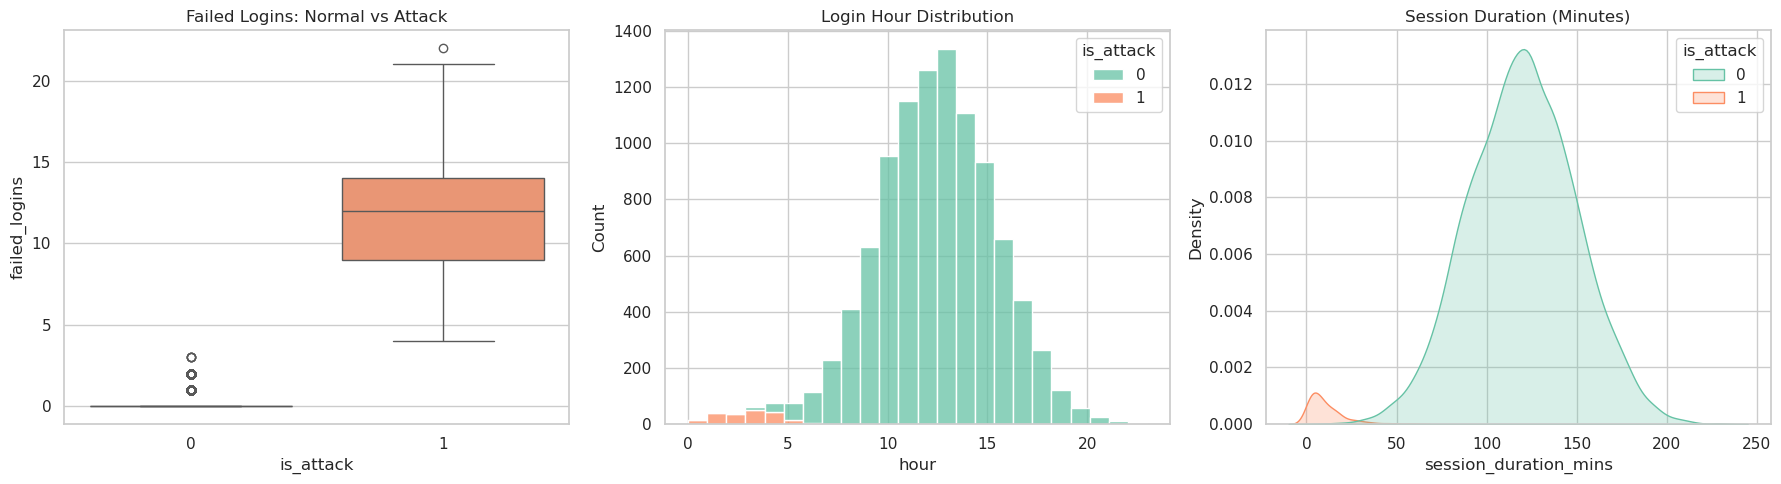

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Failed Logins Distribution
sns.boxplot(x='is_attack', y='failed_logins', data=df, ax=axes[0], palette="Set2")
axes[0].set_title('Failed Logins: Normal vs Attack')

# Hour of Day Distribution
sns.histplot(data=df, x='hour', hue='is_attack', bins=24, multiple="stack", ax=axes[1], palette="Set2")
axes[1].set_title('Login Hour Distribution')

# Session Duration
sns.kdeplot(data=df, x='session_duration_mins', hue='is_attack', fill=True, ax=axes[2], palette="Set2")
axes[2].set_title('Session Duration (Minutes)')

plt.tight_layout()
plt.show()

### 3. Anomaly Detection (Isolation Forest)
Since our data only contains 2% anomalies, we will drop the ground truth labels and let an unsupervised **Isolation Forest** model attempt to find the malicious events.

We will scale the features first to ensure distance/splitting metrics aren't heavily biased by larger numerical ranges (like session duration compared to hours).

Detection Results:
predicted_anomaly
0    9800
1     200
Name: count, dtype: int64

--- Model Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9800
           1       0.99      0.99      0.99       200

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



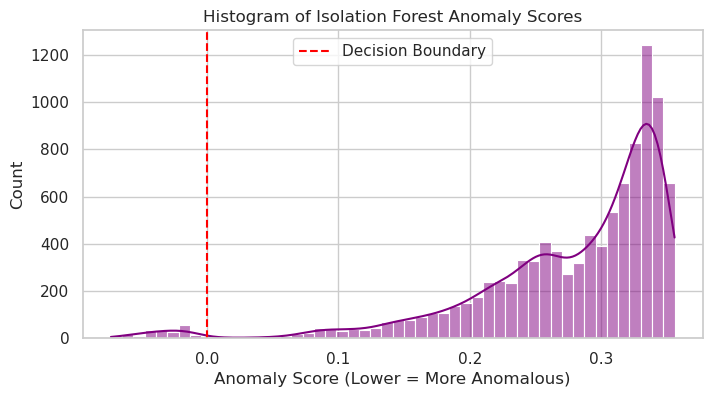

In [19]:
features = ['failed_logins', 'hour', 'session_duration_mins']
X = df[features]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest
# Contamination set to 0.02 since we know our rough anomaly rate in this environment
iso_forest = IsolationForest(contamination=0.02, random_state=42)
iso_preds = iso_forest.fit_predict(X_scaled)
anomaly_scores = iso_forest.decision_function(X_scaled)

# Map predictions (-1 is anomaly, 1 is normal in sklearn)
df['predicted_anomaly'] = [1 if x == -1 else 0 for x in iso_preds]
df['anomaly_score'] = anomaly_scores

print("Detection Results:")
print(df['predicted_anomaly'].value_counts())
print("\n--- Model Evaluation ---")
# Compare our ground truth (is_attack) with the model's predictions
print(classification_report(df['is_attack'], df['predicted_anomaly']))

# Plot Anomaly Scores
plt.figure(figsize=(8, 4))
sns.histplot(df['anomaly_score'], bins=50, kde=True, color="purple")
plt.title('Histogram of Isolation Forest Anomaly Scores')
plt.xlabel('Anomaly Score (Lower = More Anomalous)')
plt.axvline(x=0, color='red', linestyle='--', label='Decision Boundary')
plt.legend()
plt.show()

### 4. Visualize Anomalies on a 2D Projection (PCA)
To understand how well the Isolation Forest separated our data, we will reduce the 3-dimensional feature space down to 2 dimensions using **PCA** (Principal Component Analysis).

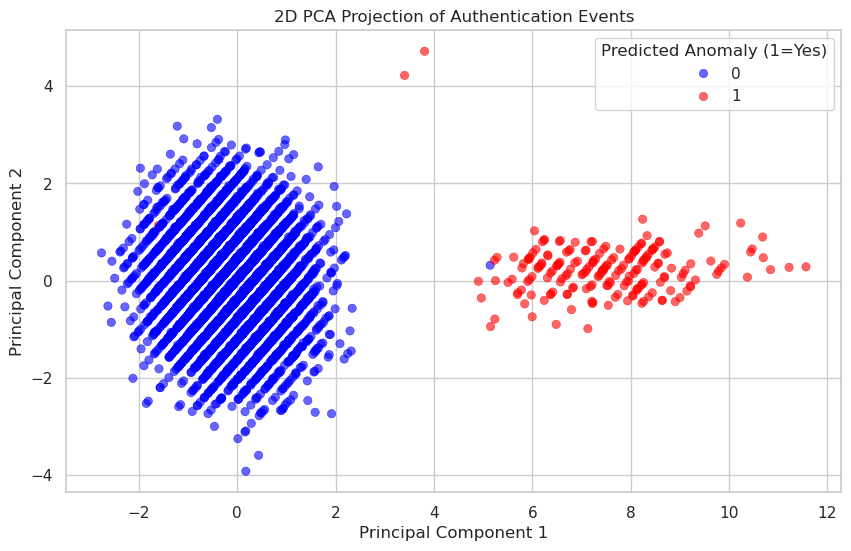

In [20]:
# Apply PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

# Visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='pca_1', y='pca_2', 
    hue='predicted_anomaly', 
    data=df, 
    palette={0: 'blue', 1: 'red'}, 
    alpha=0.6, 
    edgecolor=None
)

plt.title("2D PCA Projection of Authentication Events")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Predicted Anomaly (1=Yes)")
plt.show()

### 5. Conclusion

Looking at the 2D PCA projection, we can clearly see the structure of the authentication data.

Normal behavior forms a dense, tight cluster spanning horizontally across the center of the graph, representing typical business hour logins with standard session times. 

The anomalies (marked in red) appear as highly isolated groups branching significantly away from the main cluster. Because the Isolation Forest algorithm isolates observations by randomly selecting a feature and a split value, it easily sliced off the malicious data points due to their extreme values (high failed logins and highly abnormal hours). This confirms that the model successfully separated the T1110 and T1078 ATT&CK behaviors from benign user activity.